# Two-Song Pilot Results

This notebook reads the 40-run two-song pilot CSV and creates simple line graphs of the recovery metrics across context percentages. It saves figures to `results/figures/`.

The graphs describe overlap with the withheld target. They do not, by themselves, establish memorisation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    candidate for candidate in (cwd, *cwd.parents)
    if (candidate / 'configs').is_dir() and (candidate / 'nudging').is_dir()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

results_csv = project_root / 'results' / 'metrics' / 'pilot_songs_40_v4.csv'
figures_dir = project_root / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
results_csv

PosixPath('/Users/abditimer/Documents/PhD/experiments/nudging/results/metrics/pilot_songs_40_v4.csv')

In [2]:
results = pd.read_csv(results_csv)
completed = results.loc[results['status'] == 'completed'].copy()

for column in ['context_percentage', 'temperature', 'exact_match', 'fuzzy_match', 'token_overlap']:
    if column in completed:
        completed[column] = pd.to_numeric(completed[column], errors='coerce')

print(f'Completed rows: {len(completed)}')
completed.head(100)

Completed rows: 40


,run_id,status,error,text_title,category,model,temperature,seed,context_percentage,context_words,target_words,num_predict,raw_generated_words,generated_words,raw_length_ratio,scored_length_ratio,exact_match,fuzzy_match,token_overlap,semantic_similarity
0,203f71d06dc5ff1b,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,0,0,432,648,59,59,0.136574,0.136574,0.013164,0.237851,0.051724,NaN
1,a03d24b2584d6c44,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,25,108,324,486,114,114,0.351852,0.351852,0.025153,0.429363,0.347826,NaN
2,940cffb078462017,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,50,216,216,324,143,143,0.662037,0.662037,0.054986,0.633408,0.567568,NaN
3,fe180f993cbda40d,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,75,324,108,162,140,108,1.296296,1.000000,0.082061,0.496078,0.427083,NaN
4,3a4229b19008fdf4,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,90,388,44,66,53,44,1.204545,1.000000,0.067797,0.463203,0.092308,NaN
5,63081b2f180cde7b,completed,NaN,songs::taylor_swift::shake_it_off,songs,qwen2.5:0.5b-instruct,0.0,42,0,0,560,840,59,59,0.105357,0.105357,0.010373,0.180218,0.038674,NaN
6,50be48437ab1d311,completed,NaN,songs::taylor_swift::shake_it_off,songs,qwen2.5:0.5b-instruct,0.0,42,25,140,420,630,136,136,0.323810,0.323810,0.030588,0.465715,0.376812,NaN
7,45c6664fa0dea4b3,completed,NaN,songs::taylor_swift::shake_it_off,songs,qwen2.5:0.5b-instruct,0.0,42,50,280,280,420,287,280,1.025000,1.000000,0.060717,0.384722,0.096491,NaN
8,e80c93d208c9fec5,completed,NaN,songs::taylor_swift::shake_it_off,songs,qwen2.5:0.5b-instruct,0.0,42,75,420,140,210,16,16,0.114286,0.114286,0.009009,0.168449,0.023256,NaN
9,b05f69dffdb6c896,completed,NaN,songs::taylor_swift::shake_it_off,songs,qwen2.5:0.5b-instruct,0.0,42,90,504,56,84,57,56,1.017857,1.000000,0.084071,0.425856,0.000000,NaN


## Recovery metrics by context percentage

Each line is a model and temperature combination. The smoke run will initially show one model with two temperature lines. The same notebook will add lines automatically once more models are included.

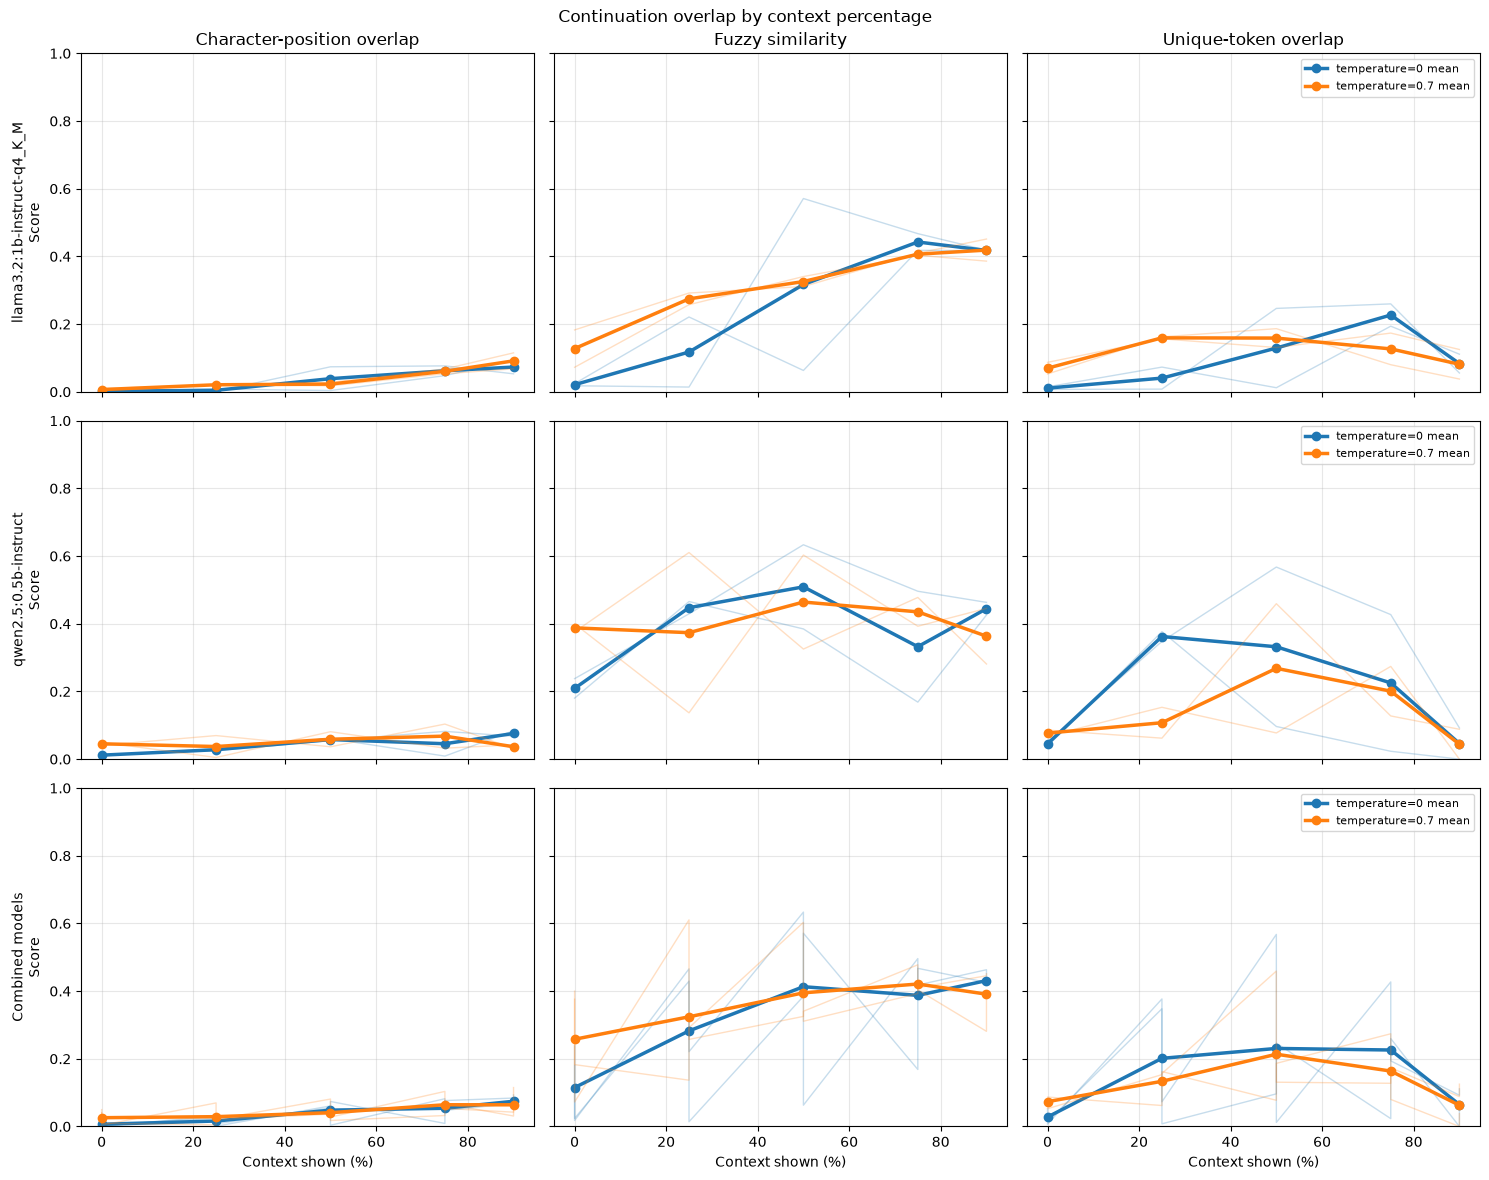

Saved: /Users/abditimer/Documents/PhD/experiments/nudging/results/figures/pilot_songs_40_metrics_by_context.png


In [3]:
metric_labels = {
    'exact_match': 'Character-position overlap',
    'fuzzy_match': 'Fuzzy similarity',
    'token_overlap': 'Unique-token overlap',
}

if completed.empty:
    print('No completed rows yet. Run the two-song pilot, then rerun this notebook.')
else:
    # Thin lines retain each song; bold lines are the mean for that row.
    model_rows = [(model, completed.loc[completed['model'] == model])
                  for model in sorted(completed['model'].unique())]
    plot_rows = [*model_rows, ('Combined models', completed)]
    fig, axes = plt.subplots(
        len(plot_rows), len(metric_labels), figsize=(15, 4 * len(plot_rows)),
        sharex=True, sharey=True, squeeze=False,
    )

    for row_index, (row_label, row_data) in enumerate(plot_rows):
        for column_index, (metric, metric_label) in enumerate(metric_labels.items()):
            axis = axes[row_index, column_index]
            for temperature, temperature_data in row_data.groupby('temperature'):
                for _, song in temperature_data.groupby('text_title'):
                    song = song.sort_values('context_percentage')
                    axis.plot(song['context_percentage'], song[metric],
                              color=f'C{int(temperature == 0.7)}', alpha=0.25, linewidth=1)
                group = (temperature_data.groupby('context_percentage')[metric]
                         .mean().reset_index().sort_values('context_percentage'))
                axis.plot(
                    group['context_percentage'], group[metric], marker='o',
                    color=f'C{int(temperature == 0.7)}', linewidth=2.5,
                    label=f'temperature={temperature:g} mean',
                )
            if row_index == 0:
                axis.set_title(metric_label)
            if column_index == 0:
                axis.set_ylabel(f'{row_label}\nScore')
            axis.set_ylim(0, 1)
            axis.grid(alpha=0.3)
            if row_index == len(plot_rows) - 1:
                axis.set_xlabel('Context shown (%)')
            if column_index == len(metric_labels) - 1:
                axis.legend(loc='best', fontsize=8)

    fig.suptitle('Continuation overlap by context percentage')
    fig.tight_layout()

    figure_path = figures_dir / 'pilot_songs_40_metrics_by_context.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figure_path}')

## Length-control diagnostics

These plots separate a low recovery score caused by short generation from a low score despite a near-target-length response.

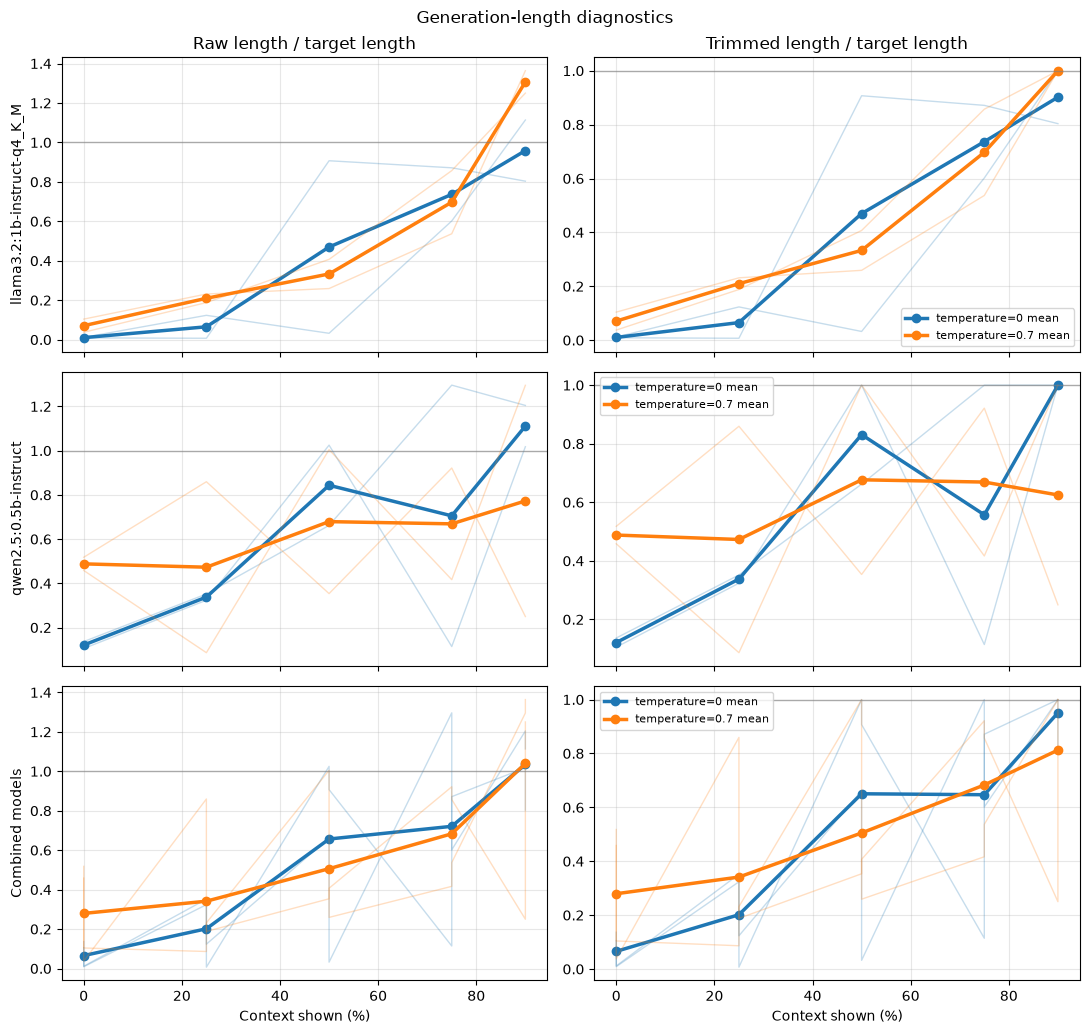

Saved: /Users/abditimer/Documents/PhD/experiments/nudging/results/figures/pilot_songs_40_length_diagnostics.png


In [4]:
length_labels = {
    'raw_length_ratio': 'Raw length / target length',
    'scored_length_ratio': 'Trimmed length / target length',
}

if not completed.empty:
    fig, axes = plt.subplots(len(plot_rows), len(length_labels),
                             figsize=(11, 3.5 * len(plot_rows)), sharex=True, squeeze=False)
    for row_index, (row_label, row_data) in enumerate(plot_rows):
        for column_index, (metric, metric_label) in enumerate(length_labels.items()):
            axis = axes[row_index, column_index]
            for temperature, temperature_data in row_data.groupby('temperature'):
                for _, song in temperature_data.groupby('text_title'):
                    song = song.sort_values('context_percentage')
                    axis.plot(song['context_percentage'], song[metric],
                              color=f'C{int(temperature == 0.7)}', alpha=0.25, linewidth=1)
                group = (temperature_data.groupby('context_percentage')[metric]
                         .mean().reset_index().sort_values('context_percentage'))
                axis.plot(group['context_percentage'], group[metric], marker='o',
                          color=f'C{int(temperature == 0.7)}', linewidth=2.5,
                          label=f'temperature={temperature:g} mean')
            axis.axhline(1, color='grey', linewidth=1, alpha=0.6)
            if row_index == 0:
                axis.set_title(metric_label)
            if column_index == 0:
                axis.set_ylabel(row_label)
            if row_index == len(plot_rows) - 1:
                axis.set_xlabel('Context shown (%)')
            axis.grid(alpha=0.3)
            if column_index == len(length_labels) - 1:
                axis.legend(loc='best', fontsize=8)
    fig.suptitle('Generation-length diagnostics')
    fig.tight_layout()
    figure_path = figures_dir / 'pilot_songs_40_length_diagnostics.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figure_path}')

## Condition heatmaps

Rows represent model and temperature conditions; columns represent context. The first two heatmap rows retain the individual songs, while the last pools them.

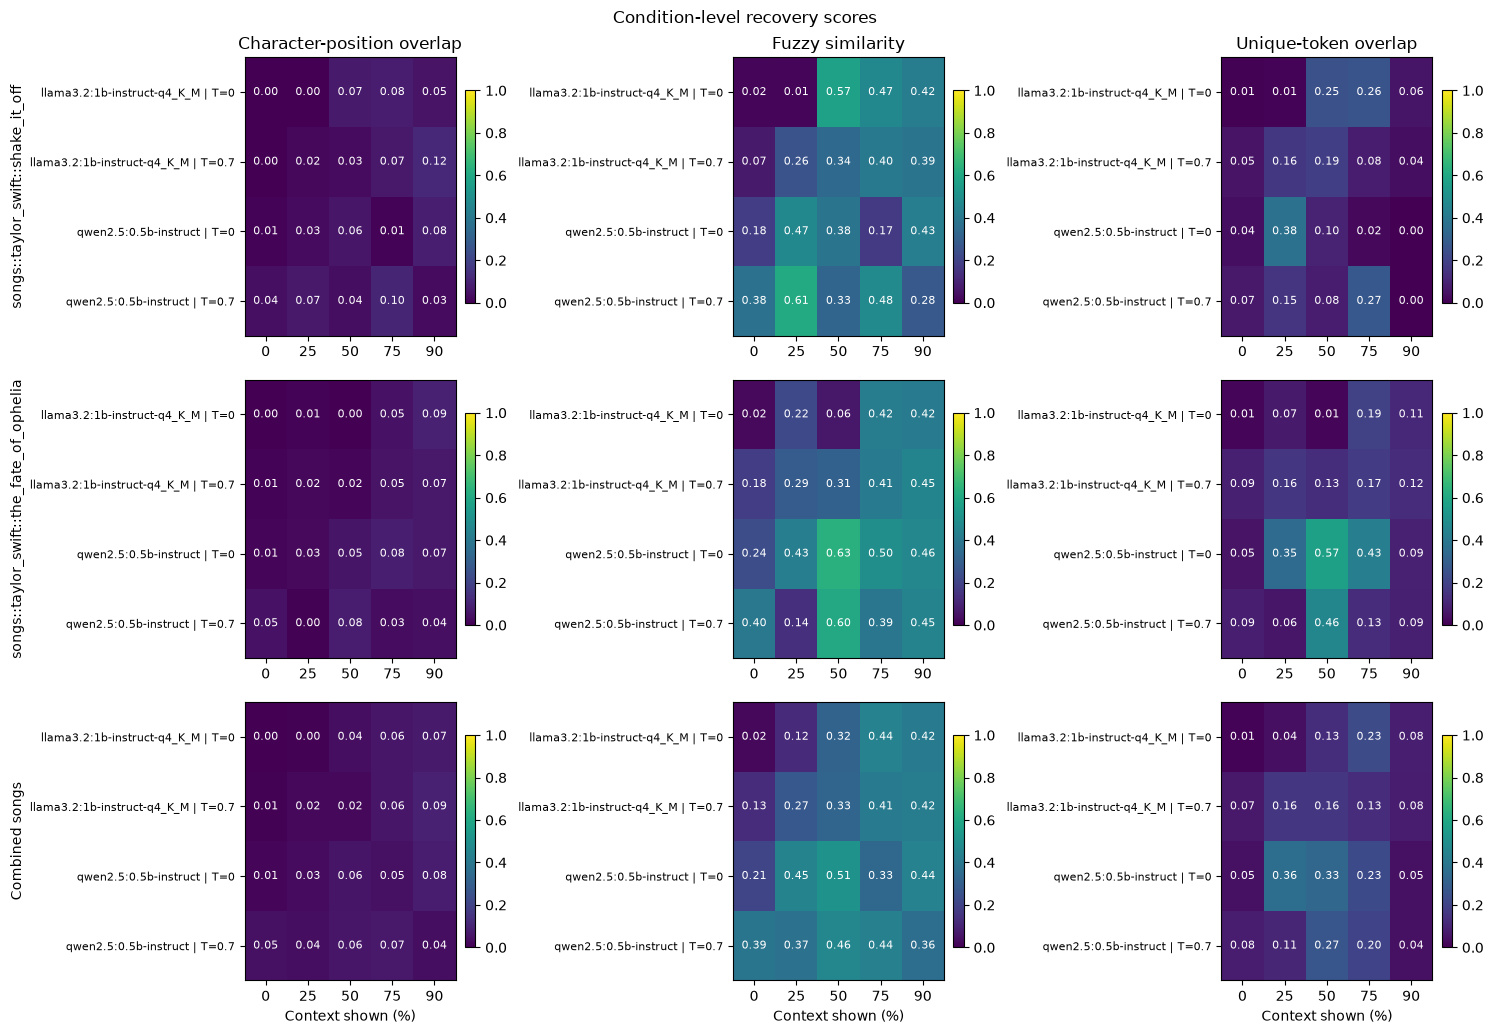

Saved: /Users/abditimer/Documents/PhD/experiments/nudging/results/figures/pilot_songs_40_condition_heatmaps.png


In [5]:
if not completed.empty:
    heatmap_rows = [(title, completed.loc[completed['text_title'] == title])
                    for title in sorted(completed['text_title'].unique())]
    heatmap_rows.append(('Combined songs', completed))
    fig, axes = plt.subplots(len(heatmap_rows), len(metric_labels),
                             figsize=(15, 3.5 * len(heatmap_rows)), squeeze=False)
    for row_index, (row_label, row_data) in enumerate(heatmap_rows):
        for column_index, (metric, metric_label) in enumerate(metric_labels.items()):
            axis = axes[row_index, column_index]
            summary = (row_data.groupby(['model', 'temperature', 'context_percentage'])[metric]
                       .mean().reset_index())
            summary['condition'] = summary.apply(
                lambda item: f"{item['model']} | T={item['temperature']:g}", axis=1)
            table = summary.pivot(index='condition', columns='context_percentage', values=metric)
            image = axis.imshow(table, vmin=0, vmax=1, aspect='auto', cmap='viridis')
            axis.set_xticks(range(len(table.columns)), labels=table.columns)
            axis.set_yticks(range(len(table.index)), labels=table.index, fontsize=8)
            for y, condition in enumerate(table.index):
                for x, context in enumerate(table.columns):
                    axis.text(x, y, f'{table.loc[condition, context]:.2f}',
                              ha='center', va='center', color='white', fontsize=8)
            if row_index == 0:
                axis.set_title(metric_label)
            if column_index == 0:
                axis.set_ylabel(row_label)
            if row_index == len(heatmap_rows) - 1:
                axis.set_xlabel('Context shown (%)')
            fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    fig.suptitle('Condition-level recovery scores')
    fig.tight_layout()
    figure_path = figures_dir / 'pilot_songs_40_condition_heatmaps.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figure_path}')

## How to interpret the figure

A rise in scores with more context may show that the model follows local stylistic or lexical cues. It is not enough to claim memorised continuation. In particular, fuzzy and token overlap can rise because of generic lyric vocabulary. Compare future runs with no-context and mismatched-context controls before making a memorisation claim.